In [13]:
import tkinter as tk
from tkinter import filedialog, ttk
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

In [16]:
class Model:
    def __init__(self,x,y,type,N,K,DC):
        mask = x > 0
        self.x = x[mask]
        self.y = y[mask]
        self.type = type
        self._N = N
        self._K = K
        self._DC = DC
    
    @property
    def N(self):
        return self._N
    @property
    def K(self):
        return self._K
    @property
    def DC(self):
        return self._DC
    
    @N.setter
    def N(self, value):
        self._N = value
    
    @K.setter
    def K(self, value):
        self._K = value

    @DC.setter
    def DC(self, value):
        self._DC = value



    def fcs_3D_1p(self,tau, N, tau_D, K, DC):
        return (
            (1 / N)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
            + DC
        )


    def fcs_3D_2p(self,tau, N, F2, tau_D, tau_D2, K, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
            * (1 + tau / (tau_D2 * K**2))**(-0.5)
        )

        return (1 / N) * (comp1 + comp2) + DC


    def fcs_3D_1p1t(self,tau, N, tau_D, K, F_T, tau_T, DC):

        diffusion = (
            (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * diffusion * triplet + DC


    def fcs_3D_2p1t(self,tau, N, F2, tau_D, tau_D2, K, F_T, tau_T, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
            * (1 + tau / (tau_D2 * K**2))**(-0.5)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * (comp1 + comp2) * triplet + DC


    # ---------- 2D MODELS ----------

    def fcs_2D_1p(self,tau, N, tau_D, DC):
        return (
            (1 / N)
            * (1 + tau / tau_D)**(-1)
            + DC
        )


    def fcs_2D_2p(self,tau, N, F2, tau_D, tau_D2, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
        )

        return (1 / N) * (comp1 + comp2) + DC


    def fcs_2D_1p1t(self,tau, N, tau_D, F_T, tau_T, DC):

        diffusion = (
            (1 + tau / tau_D)**(-1)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * diffusion * triplet + DC


    def fcs_2D_2p1t(self,tau, N, F2, tau_D, tau_D2, F_T, tau_T, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * (comp1 + comp2) * triplet + DC
    
    def plot(self, ax_main=None, ax_res=None):
        param_names = {
            "3D_1p":    ["N", "tau_D", "K", "DC"],
            "3D_2p":    ["N", "F2", "tau_D", "tau_D2", "K", "DC"],
            "3D_1p1t":  ["N", "tau_D", "K", "F_T", "tau_T", "DC"],
            "3D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "K", "F_T", "tau_T", "DC"],

            "2D_1p":    ["N", "tau_D", "DC"],
            "2D_2p":    ["N", "F2", "tau_D", "tau_D2", "DC"],
            "2D_1p1t":  ["N", "tau_D", "F_T", "tau_T", "DC"],
            "2D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "F_T", "tau_T", "DC"],
        }
        fixed_values = {}
        all_params = param_names[self.type]
        for p in ["N", "K", "DC"]:
            if p in all_params:
                val = getattr(self,f"_{p}")
                if val is not None:
                    fixed_values[p] = float(val)

        fit_params = [p for p in all_params if p not in fixed_values]

        func = None
        if self.type != None:
            func = getattr(self,f"fcs_{self.type}")

        def wrapper(tau, *free_params):
            param_dict = fixed_values.copy()

            for name, value in zip(fit_params, free_params):
                param_dict[name] = value

            ordered = [param_dict[p] for p in all_params]

            for p in ["N", "K", "DC"]:
                if p in all_params:
                    setattr(self,f"_{p}",param_dict[p])
                else:
                    setattr(self,f"_{p}",None)
                    

            return func(tau, *ordered)

        default_guess = {
            "N": 10,
            "tau_D": 0.1,
            "tau_D2": 1.0,
            "F2": 0.5,
            "K": 5,
            "F_T": 0.1,
            "tau_T": 0.001,
            "DC": 0
        }

        p0 = [default_guess[p] for p in fit_params]

        popt, pcov = curve_fit(
            wrapper,
            self.x,
            self.y,
            p0=p0,
            maxfev=20000
        )

        if ax_main is None or ax_res is None:
            fig, (ax_main, ax_res) = plt.subplots(2, 1, sharex=True)
            
        ax_main.set_xscale("log")
        ax_res.set_xscale("log")
        x_fit = np.logspace(np.log10(self.x.min()), np.log10(self.x.max()), 1000)
        y_fit = wrapper(x_fit, *popt)
        ax_main.scatter(self.x, self.y, s=10, color='blue', alpha=0.6, label='Experimental Data')
        ax_main.plot(self.x, self.y, label='Experimental graph')
        ax_main.plot(x_fit, y_fit, 'r-', label='3D Fit')
        y_pred = wrapper(self.x, *popt)
        residuals = self.y - y_pred
        ax_res.plot(self.x, residuals)
        ax_main.legend()


    
        


In [ ]:
class DataAnalysisApp:
    def __init__(self, root):
        self.root = root
        self.root.title("FCS FITTING APP")
        self.root.geometry("1200x800")
        self.param_win = None
        self.df = None
        # Parameter storage (IMPORTANT so it exists before use)
        self.K = None
        self.N = None
        self.DC = None

        # Internal State
        self.loaded_files = []

        self.setup_ui()

    def setup_ui(self):
        # --- Main Layout Containers ---
        self.sidebar = tk.Frame(self.root, width=250, bg="#f0f0f0", relief="sunken", borderwidth=1)
        self.sidebar.pack(side="left", fill="y")

        self.main_content = tk.Frame(self.root, bg="white")
        self.main_content.pack(side="right", expand=True, fill="both")

        # --- Sidebar Components ---
        tk.Label(self.sidebar, text="File Explorer", font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=10)

        btn_frame = tk.Frame(self.sidebar, bg="#f0f0f0")
        btn_frame.pack(fill="x", padx=5)

        tk.Button(btn_frame, text="Load Files", command=self.load_files).pack(side="left", expand=True, fill="x")
        tk.Button(btn_frame, text="Load Folder", command=self.load_folder).pack(side="left", expand=True, fill="x")

        self.file_listbox = tk.Listbox(self.sidebar, selectmode="single")
        self.file_listbox.pack(expand=True, fill="both", padx=5, pady=5)
        self.file_listbox.bind("<<ListboxSelect>>", self.on_file_select)

        # --- Top Control Bar (Fitting Options) ---
        self.controls = tk.Frame(self.main_content, height=100, relief="raised", borderwidth=1)
        self.controls.pack(side="top", fill="x")

        tk.Label(self.controls, text="Fitting Style:").grid(row=0, column=0, padx=5, pady=10)
        self.fit_style = ttk.Combobox(self.controls, values=["3D_1p","3D_1p1t","3D_2p","3D_2p1t", "2D_1p", "2D_1p1t","2D_2p","2D_2p1t"])
        self.fit_style.set("3D_1p")
        self.fit_style.grid(row=0, column=1, padx=5)

        tk.Button(self.controls, text="Set Parameters", command=self.open_param_window)\
            .grid(row=0, column=2, padx=5)

        tk.Button(self.controls, text="Update Fit", command=self.update_graphs, bg="#e1e1e1")\
            .grid(row=0, column=4, padx=10)

        # --- Graphing Area ---
        self.fig, self.axs = plt.subplots(3, 1, figsize=(8, 6), constrained_layout=True)
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.main_content)
        self.canvas.get_tk_widget().pack(expand=True, fill="both")

        self.axs[0].set_title(f"Fit: {self.fit_style.get()}")
        self.axs[1].set_title("Intensity Trace")
        self.axs[2].set_title("Residuals")

    # ---------------- PARAMETER WINDOW ----------------
    def open_param_window(self):
        self.param_win = tk.Toplevel(self.root)
        self.param_win.title("Set Parameters")

        tk.Label(self.param_win, text="K:").grid(row=0, column=0, padx=5, pady=5)
        self.k_entry = tk.Entry(self.param_win)
        self.k_entry.grid(row=0, column=1, padx=5)

        tk.Label(self.param_win, text="N:").grid(row=1, column=0, padx=5, pady=5)
        self.n_entry = tk.Entry(self.param_win)
        self.n_entry.grid(row=1, column=1, padx=5)

        tk.Label(self.param_win, text="DC:").grid(row=2, column=0, padx=5, pady=5)
        self.dc_entry = tk.Entry(self.param_win)
        self.dc_entry.grid(row=2, column=1, padx=5)

        # buttons row (FIXED)
        tk.Button(self.param_win, text="Apply", command=self.save_params)\
            .grid(row=3, column=0, padx=5, pady=10)

        tk.Button(self.param_win, text="Reset", command=self.reset_params)\
            .grid(row=3, column=1, padx=5, pady=10)
        


    def save_params(self):
        def parse(entry):
            val = entry.get().strip()
            return float(val) if val != "" else None

        self.K = parse(self.k_entry)
        self.N = parse(self.n_entry)
        self.DC = parse(self.dc_entry)
        self.update_graphs()
        self.param_win.destroy()


    def reset_params(self):
        self.K = None
        self.N = None
        self.DC = None
        self.update_graphs()
        self.param_win.destroy()

    def load_files(self):
        files = filedialog.askopenfilenames(
            filetypes=[("Data files", "*.dat *.czi *.ptu"), ("All files", "*.*")]
        )
        if files:
            for f in files:
                if f not in self.loaded_files:
                    self.loaded_files.append(f)
                    self.file_listbox.insert(tk.END, f.split("/")[-1])

    def load_folder(self):
        folder = filedialog.askdirectory()
        if folder:
            import os
            extensions = ('.dat', '.czi', '.ptu')
            for root, dirs, files in os.walk(folder):
                for file in files:
                    if file.endswith(extensions):
                        full_path = os.path.join(root, file)
                        if full_path not in self.loaded_files:
                            self.loaded_files.append(full_path)
                            self.file_listbox.insert(tk.END, file)
    
    def dat_to_df(self,dat):
        df = pd.read_csv(dat, sep='\s+', skiprows=1)
        print(df)
        return df

    def on_file_select(self, event):
        selection = event.widget.curselection()
        if selection:
            index = selection[0]
            selected_file = self.loaded_files[index]
            print(f"Loading: {selected_file}")
            df = self.dat_to_df(selected_file)
            self.df = df
            self.update_graphs()

    def update_graphs(self):
        selected_style = self.fit_style.get()
        x = self.df.iloc[:,0]
        y = self.df.iloc[:, 1]
       
        for ax in self.axs.flat:
            ax.clear()
        model = Model(x,y,selected_style,self.N,self.K,self.DC)
        model.plot(ax_main=self.axs[0],ax_res=self.axs[2])
        
        self.axs[0].set_title(f"Fit: {self.fit_style.get()}, N: {model.N}, K: {model.K}, DC: {model.DC}")
        self.axs[1].set_title("Intensity Trace")
        self.axs[2].set_title("Residuals")
  
        
        self.canvas.draw()
    

<>:131: SyntaxWarning: invalid escape sequence '\s'
<>:131: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hanni\AppData\Local\Temp\ipykernel_37276\3795612721.py:131: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(dat, sep='\s+', skiprows=1)


Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_10CP.dat
     Correlation_time_ms       G_t  Err
0               0.000002  1.500635    0
1               0.000004  1.352390    0
2               0.000005  1.289709    0
3               0.000006  1.152865    0
4               0.000007  1.165952    0
..                   ...       ...  ...
109            15.099494 -0.000246    0
110            17.616077 -0.000170    0
111            20.132659  0.000635    0
112            22.649242  0.000111    0
113            25.165824 -0.000499    0

[114 rows x 3 columns]
Loading: C:/Users/hanni/Downloads/dat-20260505T073325Z-3-001\dat\atto5651nM_10CP.dat
     Correlation_time_ms       G_t  Err
0               0.000002  1.500635    0
1               0.000004  1.352390    0
2               0.000005  1.289709    0
3               0.000006  1.152865    0
4               0.000007  1.165952    0
..                   ...       ...  ...
109            15.099494 -0.000246    0
110   

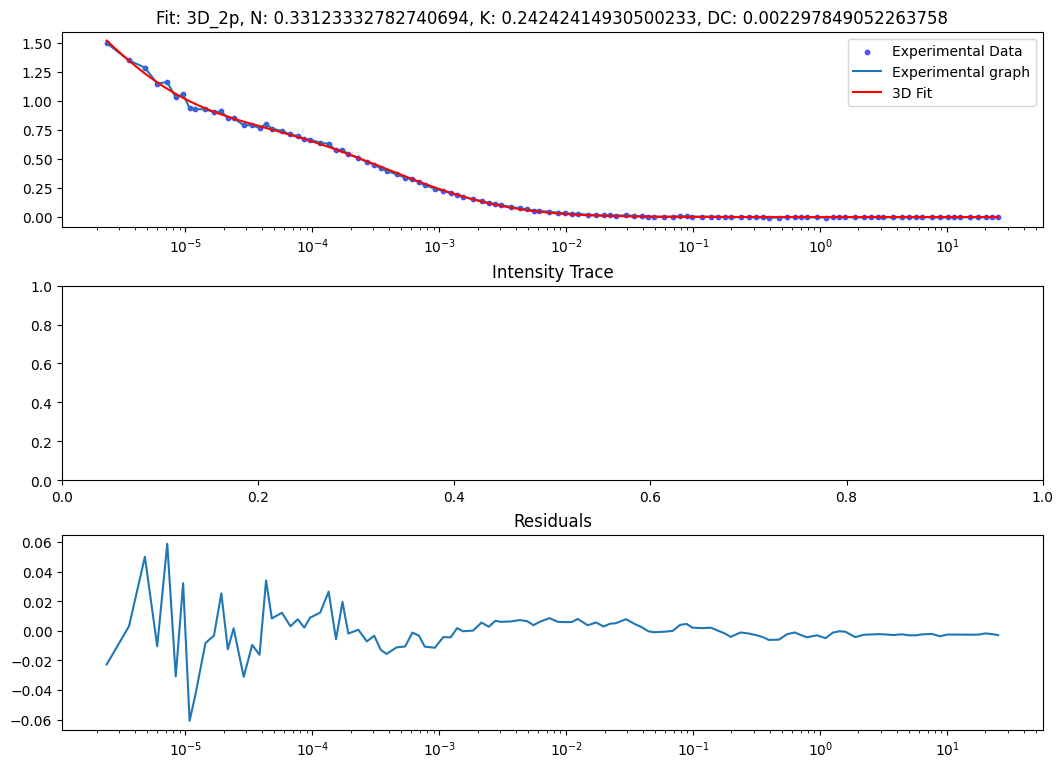

In [18]:
root = tk.Tk()
app = DataAnalysisApp(root)
root.mainloop()